Based on the dataset information, we can identify the following attributes:

**Categorical Attributes:**
*   `gender`
*   `race/ethnicity`
*   `parental level of education`
*   `lunch`
*   `test preparation course`

**Continuous Attributes:**
*   `math score`
*   `reading score`
*   `writing score`

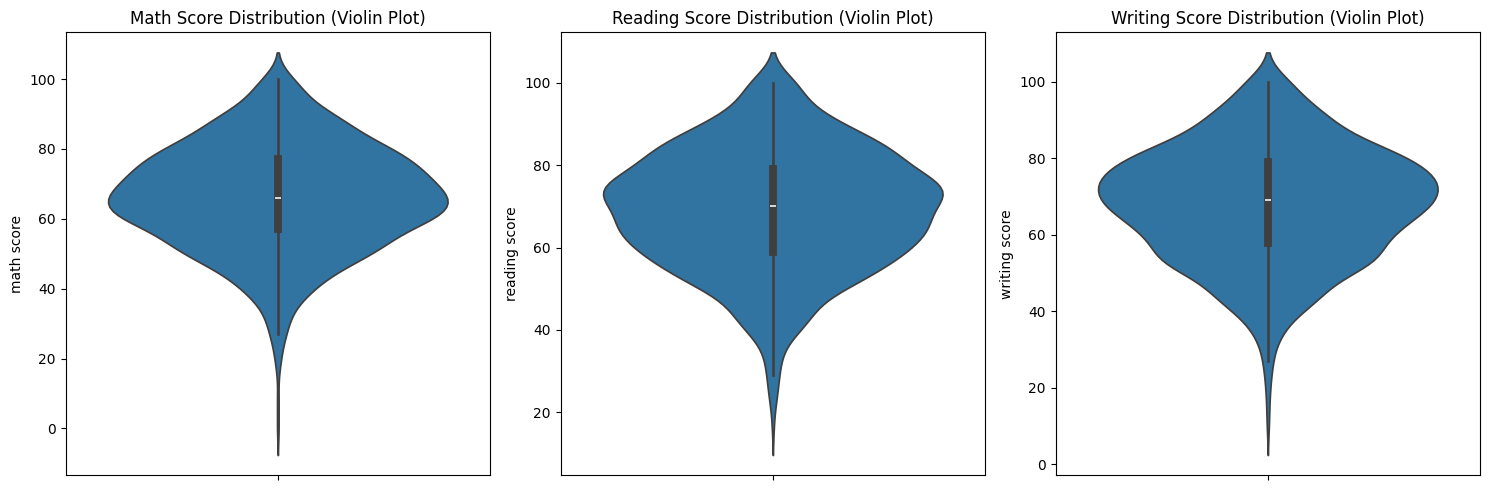

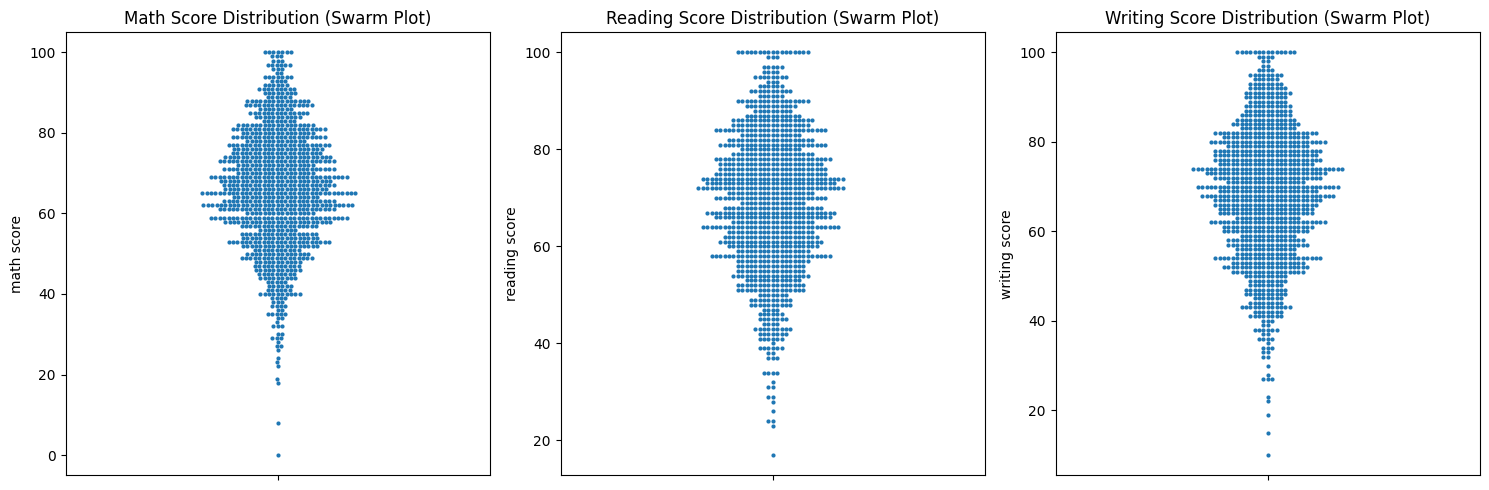

<Figure size 1000x600 with 0 Axes>

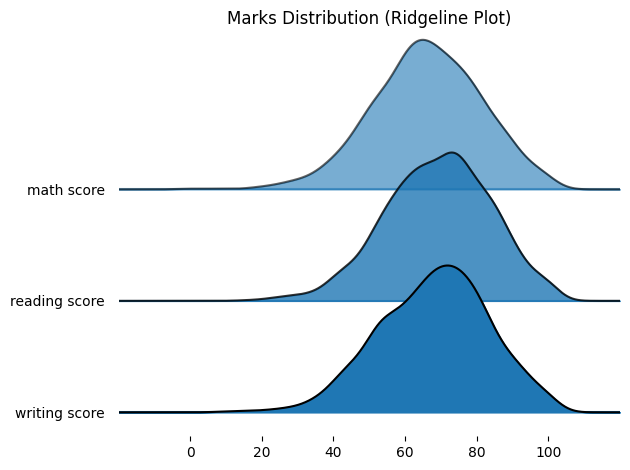

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import joypy as jp

# Violin plots for math, reading, and writing scores
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.violinplot(y=df['math score'])
plt.title('Math Score Distribution (Violin Plot)')

plt.subplot(1, 3, 2)
sns.violinplot(y=df['reading score'])
plt.title('Reading Score Distribution (Violin Plot)')

plt.subplot(1, 3, 3)
sns.violinplot(y=df['writing score'])
plt.title('Writing Score Distribution (Violin Plot)')
plt.tight_layout()
plt.show()

# Swarm plots for math, reading, and writing scores
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.swarmplot(y=df['math score'], s=3)
plt.title('Math Score Distribution (Swarm Plot)')

plt.subplot(1, 3, 2)
sns.swarmplot(y=df['reading score'], s=3)
plt.title('Reading Score Distribution (Swarm Plot)')

plt.subplot(1, 3, 3)
sns.swarmplot(y=df['writing score'], s=3)
plt.title('Writing Score Distribution (Swarm Plot)')
plt.tight_layout()
plt.show()

# Ridgeline plots for math, reading, and writing scores
score_columns = ['math score', 'reading score', 'writing score']
plt.figure(figsize=(10, 6))
jp.joyplot(df[score_columns], fade=True, xlabels=True, ylabels=True, title='Marks Distribution (Ridgeline Plot)')
plt.show()

In [ ]:
%pip install joypy

In [ ]:
# Group by parental level of education and calculate the mean of scores
education_score_summary = df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean()

# Display the summary
display(education_score_summary)

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


In [ ]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("StudentsPerformance.csv")
df.columns = [c.strip().lower() for c in df.columns]

# Derived hierarchy
df["school"] = df["race/ethnicity"].str.replace("group ", "School ", case=False)
df["class"] = df["parental level of education"].str.title() + " | " + df["lunch"].str.title()
df["student_id"] = df.index + 1

# Scores
df = df.rename(columns={
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score"
})
df["avg_score"] = df[["math_score","reading_score","writing_score"]].mean(axis=1)

# Tree visualization (Treemap)
fig = px.treemap(
    df,
    path=["school","class","student_id"],
    values="avg_score",
    color="avg_score",
    color_continuous_scale="Blues",
    hover_data={"math_score":True,"reading_score":True,"writing_score":True}
)
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("StudentsPerformance.csv")
df.columns = [c.strip().lower() for c in df.columns]
df = df.rename(columns={
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score"
})
df["school"] = df["race/ethnicity"].str.replace("group ", "School ", case=False)
df["avg_score"] = df[["math_score","reading_score","writing_score"]].mean(axis=1)

# Demo coordinates (update to your real regions if you have them)
school_geo = pd.DataFrame({
    "school":["School A","School B","School C","School D","School E"],
    "lat":[17.3850, 12.9716, 28.7041, 19.0760, 13.0827],
    "lon":[78.4867, 77.5946, 77.1025, 72.8777, 80.2707]
})

agg = df.groupby("school", as_index=False).agg(
    avg_score=("avg_score","mean"),
    students=("avg_score","size")
).merge(school_geo, on="school", how="left")

fig = px.scatter_mapbox(
    agg, lat="lat", lon="lon", hover_name="school",
    hover_data={"avg_score":":.1f","students":True,"lat":False,"lon":False},
    size="students", color="avg_score",
    color_continuous_scale="Viridis", zoom=4, height=600
)
fig.update_layout(mapbox_style="open-street-map", margin={"r":0,"t":0,"l":0,"b":0})
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("StudentsPerformance.csv")
df.columns = [c.strip().lower() for c in df.columns]
df = df.rename(columns={
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score"
})
df["school"] = df["race/ethnicity"].str.replace("group ", "School ", case=False)
df["avg_score"] = df[["math_score","reading_score","writing_score"]].mean(axis=1)

# 1) KPI summary (print or render as table)
kpis = df.agg({
    "math_score":"mean","reading_score":"mean","writing_score":"mean"
}).rename({"math_score":"Avg Math","reading_score":"Avg Reading","writing_score":"Avg Writing"})
print(kpis.round(2).to_frame("Value"))

prep_rate = (df["test preparation course"].str.lower().eq("completed").mean()*100)
print({"Pct Test Prep Completed": round(prep_rate,2)})

# 2) Average score by School
fig1 = px.bar(
    df.groupby("school", as_index=False)["avg_score"].mean().sort_values("avg_score", ascending=False),
    x="school", y="avg_score", text_auto=".1f", title="Average Score by School"
)
fig1.show()

# 3) Average score by Parental Education
fig2 = px.bar(
    df.groupby("parental level of education", as_index=False)["avg_score"].mean().sort_values("avg_score"),
    x="avg_score", y="parental level of education", orientation="h", text_auto=".1f",
    title="Average Score by Parental Education"
)
fig2.show()

# 4) Distribution by Lunch and Test Prep
fig3 = px.box(
    df, x="lunch", y="avg_score", color="test preparation course",
    title="Score Distribution by Lunch and Test Preparation"
)
fig3.show()

# 5) Subject correlation with trendline
fig4 = px.scatter(
    df, x="math_score", y="reading_score", color="gender",
    trendline="ols", title="Math vs Reading by Gender"
)
fig4.show()


             Value
Avg Math     66.09
Avg Reading  69.17
Avg Writing  68.05
{'Pct Test Prep Completed': np.float64(35.8)}


In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# Load + rename
cols = ["gender","race_ethnicity","parental_education","lunch","test_prep","math_score","reading_score","writing_score"]
df = pd.read_csv("StudentsPerformance.csv", header=None, names=cols)

# Types
cat_cols = ["gender","race_ethnicity","parental_education","lunch","test_prep"]
num_cols = ["math_score","reading_score","writing_score"]
df[cat_cols] = df[cat_cols].astype("category")
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# Derived
df["avg_score"] = df[num_cols].mean(axis=1)
df["school"] = df["race_ethnicity"].str.replace("group ", "School ", case=False)
df["class"] = df["parental_education"].str.title() + " | " + df["lunch"].str.title()
df["student_id"] = np.arange(1, len(df)+1)
